# **Osnove računalnog vida s OpenCV-jem**

## **Uvod**
Dobrodošli na naprednu radionicu robotike! Danas ćemo naučiti kako iz digitalne slike izvući informacije koje su robotu potrebne za rad (npr. boje i koordinate predmeta, veličinu predmeta i sl.).

### **Što je zapravo digitalna slika?**
Za nas je slika prikaz stvarnosti, ali za računalo je to matrica brojeva (u Pythonu koristimo `numpy` array).  
Svaka slika se sastoji od piksela (najmanja jedinica slike).  
Standardna slika u boji ima tri sloja (kanala).

##### **PAŽNJA:** Većina programa koristi **RGB** (Red-Green-Blue) sustav, ali OpenCV koristi **BGR** (Blue-Green-Red). To znači da su crvena i plava zamijenjene!


### Koordinatni sustav
U matematici je $(0,0)$ obično dolje lijevo.  
U računalnom vidu, ishodište $(0,0)$ je **gornji lijevi kut.**
- X os raste udesno.
- Y os raste prema dolje.

## Instalacija potrebnih paketa

Za instalaciju paketa koristimo Pythonov pip, modul koji služi kao package manager  
Kopirajte u terminal iduću liniju:

## **Primjer 1: Učitavanje i prvi pogled matrice**

U ovom zadatku učitavamo našu prvu sliku.

Cilj je ispisati njezine dimenzije (`shape`) kako bismo vidjeli koliko piksela ima i shvatili da se radi o običnoj listi brojeva.  
Također, isprobat ćemo pretvorbu u *Grayscale* (sive tonove) jer je s takvim slikama lakše računati.

Importanje potrebnih paketa

In [1]:
import cv2
import numpy as np 
from matplotlib import pyplot as plt

Učitaj sliku i pretvori ju u Grayscale

In [2]:
img = cv2.imread('slike/robot.png')

# Provjera je li slika dobro učitana - nije neophodno
assert img is not None, 'Greška: Slika nije pronađena! Provjeri lokaciju.'

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

Oblik slike + ispis dijela slike

In [3]:
print(f'Original shape: {img.shape}')
print(f'Grayscale shape: {gray.shape}')

print(f"Prikaz slike kao matrice brojeva : \n {gray}")

Original shape: (367, 550, 3)
Grayscale shape: (367, 550)
Prikaz slike kao matrice brojeva : 
 [[ 14   4   0 ...  49  76  98]
 [ 23  12   4 ...  46  59  69]
 [ 74  69  60 ...  93  96  83]
 ...
 [122 121 115 ... 209 210 210]
 [110 116 118 ... 207 207 206]
 [ 91  94 103 ... 204 203 201]]


**Prikaz slike (u Jupyteru)**

Prva zakomentirana linija je standardni način prikazivanja u OpenCV-u, ta funkcija otvara novi prozor s našom slikom, ali to nije povoljno za Jupyter bilježnicu, stoga koristimo funkciju `imshow` iz modula `matplotlib`.

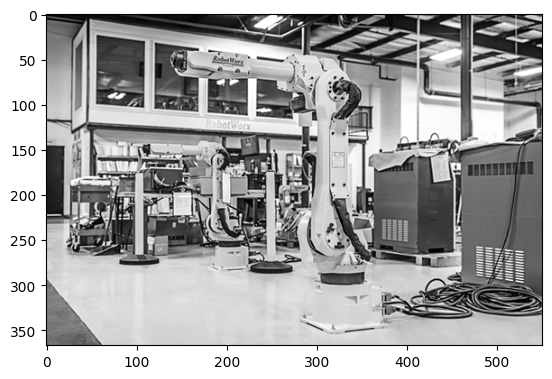

In [4]:
# cv2.imshow('Grayscale', gray)

# Prikaži sliku
plt.imshow(gray, cmap='gray')
plt.show()

#### **Zadatak:** Dobivenu crno-bijelu sliku spremite u folder slike. - **guglajte (ili AI)**
#### **Zadatak:** OpenCV ima funkcije za crtanje geometrijskih likova i ubacivanje teksta na sliku. Na neku od prethodnih slika nacrtajte proizvoljne pravce, pravokutnike i kružnice, dodajte neku riječ na sliku i sl.

## **Primjer 2: HSV filtriranje**

Umjesto da tražimo boju preko BGR-a, prebacujemo se u **HSV prostor** (Hue, Saturation, Value).

Koristimo HSV umjesto RGB (tj. BGR) zato što RGB ne odvaja intenzitet slike od informacije o boji dok HSV to radi - HSV je sličniji ljudskom opisivanju boja.  
Hue (nijansa) nam omogućuje da lakše izoliramo specifičnu boju bez obzira na to ima li na slici sjena.

Pomoću slidera (*trackbar*) ćemo pronaći točne granice plave boje i stvoriti **masku** (crno-bijelu sliku gdje je bijelo samo ono što propuštamo).

**Hint:** Hue plave boje je oko 120, a crvene 0 (boja kontrolera je oko 170).

**Napomena:** Inače se Hue interpretira kao nijansa po kružnici (360 stupnjeva), ali u OpenCV Hue ide do 180 stupnjeva, pa primjerice plavoj boji inače odgovara Hue vrijednost 240, a u OpenCV-ju 120.

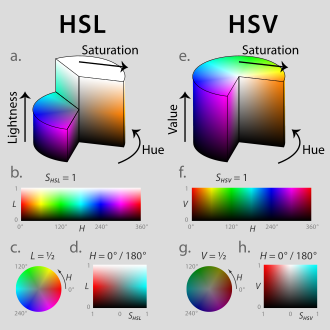

In [ ]:
# Pomoćna funkcija koja ne radi ništa, ali je OpenCV treba za trackbare
def do_nothing(x):
    pass

# Funkcija za brzo postavljanje svih slidera
def set_trackbars(hmin, hmax, smin, smax, vmin, vmax):
    cv2.setTrackbarPos("Min H", "Slideri", hmin)
    cv2.setTrackbarPos("Max H", "Slideri", hmax)
    cv2.setTrackbarPos("Min S", "Slideri", smin)
    cv2.setTrackbarPos("Max S", "Slideri", smax)
    cv2.setTrackbarPos("Min V", "Slideri", vmin)
    cv2.setTrackbarPos("Max V", "Slideri", vmax)

upute_img = np.zeros((250, 500, 3), dtype=np.uint8)
font = cv2.FONT_HERSHEY_SIMPLEX

cv2.putText(upute_img, "UPUTE ZA TIPKOVNICU:", (20, 40), font, 1.3, (255, 255, 255), 2)
cv2.putText(upute_img, "- 'R' : RESET", (20, 80), font, 1.2, (0, 255, 0), 1)
cv2.putText(upute_img, "- 'B' : PLAVA PRESET", (20, 110), font, 1.2, (255, 100, 0), 1)
cv2.putText(upute_img, "- 'C' : CRVENA PRESET", (20, 140), font, 1.2, (0, 0, 255), 1)
cv2.putText(upute_img, "- 'Q' : IZLAZ", (20, 180), font, 1.2, (200, 200, 200), 1)

# 1. Učitaj sliku
img = cv2.imread('slike/predmeti.jpeg')
assert img is not None, 'Greška: Slika nije pronađena! Provjeri putanju.'

# Skaliranje slike
# npr. scale = 0.2 odgovara veličini 20% originalne slike
scale = 0.2
img = cv2.resize(img, None, fx=scale, fy=scale)

# Prebacujemo sliku u HSV format odmah, da ne radimo to u petlji stalno
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# 2. Kreiramo kontrolni prozor za slidere
cv2.namedWindow("Slideri", cv2.WINDOW_NORMAL)
cv2.startWindowThread()
cv2.resizeWindow("Slideri", 500, 600)

# Kreiramo 6 slidera za HSV (Donja i Gornja granica)
# Hue ide do 179 u OpenCV-u, Saturation i Value do 255
cv2.createTrackbar("Min H", "Slideri", 0, 179, do_nothing)
cv2.createTrackbar("Max H", "Slideri", 179, 179, do_nothing)
cv2.createTrackbar("Min S", "Slideri", 0, 255, do_nothing)
cv2.createTrackbar("Max S", "Slideri", 255, 255, do_nothing)
cv2.createTrackbar("Min V", "Slideri", 0, 255, do_nothing)
cv2.createTrackbar("Max V", "Slideri", 255, 255, do_nothing)

while True:
    cv2.imshow("Slideri", upute_img)

    # Očitaj trenutne vrijednosti sa slidera
    h_min = cv2.getTrackbarPos("Min H", "Slideri")
    h_max = cv2.getTrackbarPos("Max H", "Slideri")
    s_min = cv2.getTrackbarPos("Min S", "Slideri")
    s_max = cv2.getTrackbarPos("Max S", "Slideri")
    l_min = cv2.getTrackbarPos("Min V", "Slideri")
    l_max = cv2.getTrackbarPos("Max V", "Slideri")

    # Definiraj opsege boja na temelju vrijednosti sa slidera
    lower_hsv = np.array([h_min, s_min, l_min])
    upper_hsv = np.array([h_max, s_max, l_max])

    # 3. Kreiraj masku (samo npr. plavi dijelovi postaju bijeli (1), ostalo crno (0))
    mask = cv2.inRange(hsv, lower_hsv, upper_hsv)

    # Primijeni masku na originalnu sliku da vidimo samo izoliranu boju
    result = cv2.bitwise_and(img, img, mask=mask)

    # Prikaz prozora
    cv2.imshow("Originalna slika", img)
    cv2.imshow("Maska (Binary)", mask)
    cv2.imshow("Rezultat (Izolirano)", result)

    key = cv2.waitKey(1) & 0xFF

    if key == ord('q'):
        break
    elif key == ord('r'):
        set_trackbars(0, 179, 0, 255, 0, 255)
    elif key == ord('b'):
        set_trackbars(100, 130, 100, 255, 45, 255)
    elif key == ord('c'):
        set_trackbars(165, 179, 100, 255, 45, 255)
    

# Zatvori sve prozore i oslobodi memoriju
cv2.destroyAllWindows()

#### **Zadatak:** Umjesto slika predmeta učitajte sliku tigra te izolirajte narančaste pruge.

## **Primjer 3: Detekcija rubova**

Kako bi robot prepoznao kutiju ili rub stola, moramo pronaći linije.

Koristit ćemo **Canny algoritam** i **Sobel algoritam**.  
Canny traži mjesta na slici gdje se intenzitet boje naglo mijenja.  
Sobel računa intenzitet promjene svjetline piksela u vodoravnom i okomitom smjeru.

Prije toga ćemo primijeniti *blur* (zamućenje) kako bismo uklonili "šum" (sitne nepravilnosti koje bi algoritam krivo protumačio kao rubove).


In [6]:
# Učitaj sliku (npr. slika UR robotske ruke ili neke kutije)
img = cv2.imread('slike/predmeti.jpeg')
assert img is not None, 'Greška: Slika nije pronađena! Provjeri lokaciju.'

# 1. Priprema: Smanji sliku i pretvori u sivu (Grayscale)
scale = 0.2
img = cv2.resize(img, None, fx=scale, fy=scale)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 2. Kreiranje prozora i slidera za Canny pragove
cv2.namedWindow("Slideri")
cv2.startWindowThread()

cv2.createTrackbar("Canny Low", "Slideri", 50, 500, do_nothing)
cv2.createTrackbar("Canny High", "Slideri", 150, 500, do_nothing)
cv2.createTrackbar("Sobel Dx", "Slideri", 1, 3, do_nothing)
cv2.createTrackbar("Sobel Dy", "Slideri", 1, 3, do_nothing)
cv2.createTrackbar("Blur Amount", "Slideri", 2, 10, do_nothing)

print("Pomiči slidere da izoliraš rubove objekta. 'Q' za izlaz.")

while True:
    # Očitaj vrijednosti
    canny_low = cv2.getTrackbarPos("Canny Low", "Slideri")
    canny_high = cv2.getTrackbarPos("Canny High", "Slideri")
    sobel_dx = cv2.getTrackbarPos("Sobel Dx", "Slideri")
    sobel_dy = cv2.getTrackbarPos("Sobel Dy", "Slideri")
    blur_amt = cv2.getTrackbarPos("Blur Amount", "Slideri")

    # Obje vrijednosti ne smiju biti 0, inače cv2.Sobel baca grešku
    if sobel_dx == sobel_dy == 0:
        cv2.setTrackbarPos("Sobel Dx", "Slideri", 1)
        cv2.setTrackbarPos("Sobel Dy", "Slideri", 1)
        sobel_dx = 1
        sobel_dy = 1
    
    # 3. Obrada
    # Prvo blurramo da maknemo sitne smetnje
    # Napomena, blur_val mora biti neparan zbog načina rada Gaussian Blur algoritma, istražite zašto
    blurred = cv2.GaussianBlur(gray, (2*blur_amt+1, 2*blur_amt+1), 0)
    
    # Canny i Sobel algoritmi
    canny = cv2.Canny(blurred, canny_low, canny_high)
    sobelxy = cv2.Sobel(blurred, ddepth=cv2.CV_64F, dx=sobel_dx, dy=sobel_dy, ksize=5)

    # Prikaz (Zamućeno vs Rubovi)
    cv2.imshow("Slideri", np.ones((1, 500, 3), dtype=np.uint8))
    cv2.imshow("Zamućeno (Sivo)", blurred)
    cv2.imshow("Canny Detekcija", canny)
    cv2.imshow("Sobel Detekcija", sobelxy)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break


cv2.destroyAllWindows()
cv2.waitKey(1)

Pomiči slidere da izoliraš rubove objekta. 'Q' za izlaz.


-1

## **Primjer 4: Detektiranje i praćenje loptice uživo**


Kako pristupiti kameri preko OpenCV-ja?

In [ ]:
cap = cv2.VideoCapture(0) # 0 je default kamera (možda se treba postaviti na 1, ovisno o kameri i računalu)

while True:
    ret, frame = cap.read()
    
    # ret je bool koji provjerava je li frame (slika) uspješno pročitana
    if not ret:
        break
    
    cv2.imshow("Slika s kamere", frame)

    if cv2.waitKey(1) == ord('q'):
        break

# Otpuštanje objekta kamere kako bi ju mogli koristiti drugi procesi,
# slično kao file.close() kod rada s datotekama u Pythonu
cap.release()
cv2.destroyAllWindows()

### Praćenje objekta

In [ ]:
cap = cv2.VideoCapture(0)

cv2.namedWindow("Mask")

# Početne postavke za zelenu boju
# Napomena: prvi brojčani argument funkcije createTrackbar je početna vrijednost slidera (40, 80, 100, ...)
cv2.createTrackbar("H Min", "Mask",  40, 179, do_nothing) 
cv2.createTrackbar("H Max", "Mask",  80, 179, do_nothing) 
cv2.createTrackbar("S Min", "Mask", 100, 255, do_nothing)  
cv2.createTrackbar("S Max", "Mask", 255, 255, do_nothing)  
cv2.createTrackbar("V Min", "Mask",  70, 255, do_nothing)  
cv2.createTrackbar("V Max", "Mask", 255, 255, do_nothing) 

while True:
    ret, frame = cap.read()
    
    if not ret:
        break

    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

    h_min = cv2.getTrackbarPos("H Min", "Mask")
    h_max = cv2.getTrackbarPos("H Max", "Mask")
    s_min = cv2.getTrackbarPos("S Min", "Mask")
    s_max = cv2.getTrackbarPos("S Max", "Mask")
    v_min = cv2.getTrackbarPos("V Min", "Mask")
    v_max = cv2.getTrackbarPos("V Max", "Mask")

    lower_blue = np.array([h_min, s_min, v_min])
    upper_blue = np.array([h_max, s_max, v_max])
    mask = cv2.inRange(hsv, lower_blue, upper_blue)

    # Nije nam potrebna druga povratna vrijednost cv2.findContours funkcije,
    # možemo koristiti '_' kako bismo 'ignorirali' tu vrijednost
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        # Najveći blob
        biggest = max(contours, key=cv2.contourArea)
 
        # Blob mora biti dovoljno velik
        if cv2.contourArea(biggest) > 500:

            # -----------------------
            
            # Odredi najmanju opisanu kružnicu oko bloba
            (x, y), radius = cv2.minEnclosingCircle(biggest)
 
            # Crtanje kružnice i središta
            cv2.circle(frame, (int(x), int(y)), int(radius), (0, 255, 0), 3)
            cv2.circle(frame, (int(x), int(y)), 5, (0, 0, 255), -1)

            # -----------------------

    cv2.imshow("Webcam", frame)
    cv2.imshow("Mask", mask)

    if cv2.waitKey(1) == ord('q'):
        break
 
cap.release()
cv2.destroyAllWindows()

#### **Zadatak:** Namjestite slidere da plava loptica bude dobro izolirana i zatim te vrijednosti postavite za default vrijednosti slidera.

#### **Zadatak:** Umjesto crtanja kružnice (kod unutar `------`), odredite lokaciju težišta (koristeći funkciju/e unutar cv2 i numpy) te stavite crvenu točku u to težište, uz tu točku napišite lokaciju i površinu bloba npr. "x = 2, y = 1, A = 100" - **guglajte (ili AI)**